### GA4 Ecommerce EDA
Loading the 8 tables I exported from Bigquery. 
Need to make sure the numbers match with SQl, if not, back to SQL 


In [1]:
import pandas as pd
import numpy as np

# Just setting this so I don't get scientific notation everywhere
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# file location
DATA_DIR = '../docs/'


files = {
    'channel': 'm_channel_performance.csv',
    'geo': 'm_daily_pattern_by_geo.csv',
    'activation': 'm_first_visit_activation.csv',
    'funnel': 'm_funnel_by_device_channel.csv',
    'retention': 'm_retention_curve.csv',
    'visits': 'm_visits_before_purchase.csv',
    'category': 'm_category_performance_geo_device.csv',
    'revenue': 'm_revenue_distribution.csv',
}

# Load 
dfs = {}
for name, f in files.items():
    dfs[name] = pd.read_csv(DATA_DIR + f)
    print(f"{name:15} loaded. Shape: {dfs[name].shape}")

channel         loaded. Shape: (5, 4)
geo             loaded. Shape: (35, 5)
activation      loaded. Shape: (1, 3)
funnel          loaded. Shape: (15, 5)
retention       loaded. Shape: (14, 6)
visits          loaded. Shape: (1, 2)
category        loaded. Shape: (1534, 5)
revenue         loaded. Shape: (1, 5)


 ##### --- 1. Quick Validation ---

 Just making sure the export is fine.


In [2]:
# 1. Channel
df = dfs['channel']
assert len(df) == 5, "Wait, why isn't this 5 rows?"
print("Channel check: OK.")

# 2. Geo
df = dfs['geo']
assert len(df) == 35, "Expected 35 rows (7 days * 5 groups)"
print("Geo check: OK.")

# 3. Activation
df = dfs['activation']
# Just checking if the rate is between 0 and 1. If it's > 1, something is broken.
assert 0 <= df['view_to_cart_rate_first_day'].iloc[0] <= 1
print("Activation check: OK.")

# 4. Funnel
df = dfs['funnel']
# If purchase > cart, the query has some issue.
violations = df[(df['purchase_users'] > df['add_to_cart_users']) | df['add_to_cart_users'] > df['view_item_users'] ]
assert violations.empty, "Funnel logic is broken somewhere."
print("Funnel check: OK.")

# 5. Retention
df = dfs['retention']
df['cohort_week'] = pd.to_datetime(df['cohort_week'])
# Just making sure dates look right.
assert df['cohort_week'].isna().sum() == 0, "Null cohort_week found; stale table??"
assert df['cohort_week'].min() >= pd.Timestamp('2020-11-01')
assert df['cohort_week'].max() <= pd.Timestamp('2021-01-31')
print("Retention check: OK.")

# 6. Visits
df = dfs['visits']
assert 0 < df['avg_active_days_before_purchase'].iloc[0] < 30
print("Visits check: OK.")

# 7. Category
# This one had that weird 'Unknown' bucket issue
df = dfs['category']
total_rev = df['total_revenue'].sum()
print(f"Total revenue: {total_rev:,.2f}")
# Allowing a small margin of error because of rounding in SQL vs Pandas
assert abs(total_rev - 362110) < 500 

# check no junk category labels leaked through
junk = df[df['category_clean'].isin(['(not set)', '']) | df['category_clean'].isna()]
assert junk.empty, f"Junk category values leaked through:\n{junk}"

## confirm nulls are still confined to Unknown only (43 in notebook vs 44 as earlier seen in raw csv inspeaction)
nulls = df[df['total_revenue'].isna()]
print(nulls['category_clean'].value_counts())
assert (nulls['category_clean'] == 'Unknown').all(), "Nulls found outside Unknown category!"
print("Category check: OK.")

# 8. Revenue Dist
df = dfs['revenue']
assert len(df) == 1
assert abs(df['median_rev'].iloc[0] - 48.0) < 1, "Median does not match finding"
assert abs(df['mean_rev'].iloc[0] - 69.09) < 1, "Mean doesn't match exploration finding"
print("Revenue dist check: OK.")

Channel check: OK.
Geo check: OK.
Activation check: OK.
Funnel check: OK.
Retention check: OK.
Visits check: OK.
Total revenue: 362,110.00
category_clean
Unknown    43
Name: count, dtype: int64
Category check: OK.
Revenue dist check: OK.


#### --- 2. EDA Stuff ---


In [3]:
# Let's see what we're working with
dfs['channel'].describe()

,total_visitors,total_purchasers,conversion_rate
count,5.00,5.00,5.00
mean,"64,928.20",946.00,0.01
std,"35,002.14",459.09,0.00
min,"15,528.00",152.00,0.01
25%,"55,495.00","1,026.00",0.01
50%,"65,309.00","1,054.00",0.01
75%,"75,951.00","1,175.00",0.02
max,"112,358.00","1,323.00",0.02


In [4]:
# Category performance is the big one. Let's look at the top categories.
# Man, I really need to clean these names up properly later.
dfs['category']['category_clean'].value_counts().head(10)

category_clean
Apparel                173
New                    119
Shop by Brand          111
Campus Collection      111
Accessories            103
Drinkware               99
Office                  98
Unknown                 96
Uncategorized Items     93
Lifestyle               93
Name: count, dtype: int64

In [5]:
# Total revenue by country. Does this look right?
# (Self-note: Need to check if 'United States' is at the top, it usually is)
dfs['category'].groupby('country_clean')['total_revenue'].sum().sort_values(ascending=False).head(5)

country_clean
United States    160,566.00
India             34,984.00
Canada            32,785.00
United Kingdom    11,461.00
Spain              7,675.00
Name: total_revenue, dtype: float64

In [6]:
# Pivot table for the report later
pivot_df = dfs['category'].pivot_table(
    index='category_clean',
    columns='device_category',
    values='total_revenue',
    aggfunc='sum',
    fill_value=0
)
pivot_df.sort_values('desktop', ascending=False).head(10)

device_category,desktop,mobile,tablet
category_clean,,,
Apparel,"98,030.00","70,057.00","3,640.00"
New,"14,865.00","10,554.00",394.00
Bags,"13,197.00","10,115.00",548.00
Campus Collection,"11,629.00","7,996.00",436.00
Accessories,"11,067.00","6,484.00",264.00
Uncategorized Items,"10,586.00","6,329.00",479.00
Shop by Brand,"10,451.00","6,407.00",102.00
Drinkware,"8,970.00","6,553.00",284.00
Lifestyle,"8,343.00","4,975.00",105.00


##### --- 3. Nulls ---
Checking for nulls. 
Note that 'category_performance' has some nulls in revenue, but that's expected for the 'Unknown' category.

In [7]:
for name, df in dfs.items():
    if df.isna().sum().sum() > 0:
        print(f"Nulls found in {name}:")
        print(df.isna().sum()[df.isna().sum() > 0])
        print("-" * 20)

Nulls found in category:
total_revenue    43
dtype: int64
--------------------


##### --- 4. Stats ---
 Right-skewed revenue. Standard ecommerce stuff.

In [8]:
# Right-skewed revenue. Standard ecommerce stuff.
rev = dfs['revenue'].iloc[0]
print(f"Mean: {rev['mean_rev']:.2f}")
print(f"Median: {rev['median_rev']:.2f}")
# If mean > median, it's right-skewed. 
# Definitely use median for the presentation. Stakeholders always get confused by means.

Mean: 69.09
Median: 48.00


#### --4b. Activation and Visits quick check--

these two tables are singlw row aggregates already confirmed in section 1, surfacing the actual numbers here so they are a part if the narrativate and not just present as validation. 

In [12]:
act = dfs['activation'].iloc[0]
vis = dfs['visits'].iloc[0]

print(f"Viewed item on first day: {act['viewed_item_first_day']:,}")
print(f"Added to cart on first day: {act['added_to_cart_first_day']:,}")
print(f"View -> cart rate (day1): {act["view_to_cart_rate_first_day"]:.1%}")
print()
print(f"Avg active days before purchase: {vis["avg_active_days_before_purchase"]:.2f}")
print(f"Median active days before purchase: {vis['median_active_days_before_purchase']:}.0f")

Viewed item on first day: 57,258.0
Added to cart on first day: 9,967.0
View -> cart rate (day1): 17.4%

Avg active days before purchase: 1.81
Median active days before purchase: 1.0.0f


##### TODO:
 - Need to build the visualizations next. 
 - Bar charts for channels.
 - Line chart for retention.
 - Maybe a heatmap for the day of week stuff?

In [13]:
# TODO: make sure output dir actually exists before running this, 

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
print("Starting chart generation...")

Starting chart generation...


##### --- Chart 1: Channel Conversion ---
 Sort out the channels by conversion rate

In [20]:
import os
os.makedirs('../outputs/charts/', exist_ok = True)


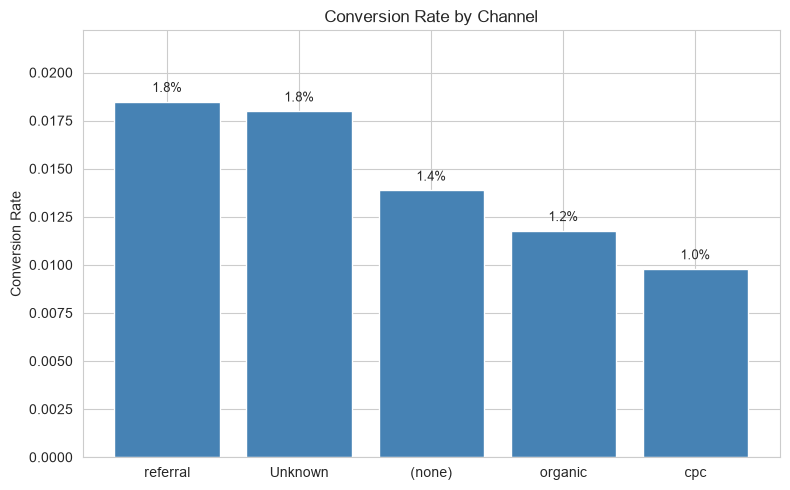

In [21]:

fig, ax = plt.subplots(figsize=(8, 5))

# grab data
channel_df = dfs['channel'].sort_values('conversion_rate', ascending=False)

# plot bars
bars = ax.bar(channel_df['medium_clean'], channel_df['conversion_rate'], color='steelblue')
ax.set_ylabel('Conversion Rate')
ax.set_title('Conversion Rate by Channel')

# let's give a bit of headroom at the top so labels don't get cut off
max_val = channel_df['conversion_rate'].max()
ax.set_ylim(0, max_val * 1.2)

# put text on top of bars manually
for i, v in enumerate(channel_df['conversion_rate']):
    ax.text(i, v + 0.0005, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/charts/channel_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

# NOTE: The highest converting channel isn't the biggest volume one!
# Keep this in mind when talking to marketing about budget reallocation.

##### --- Chart 2: Retention Curve ---
 Grab active weeks 1 through 4

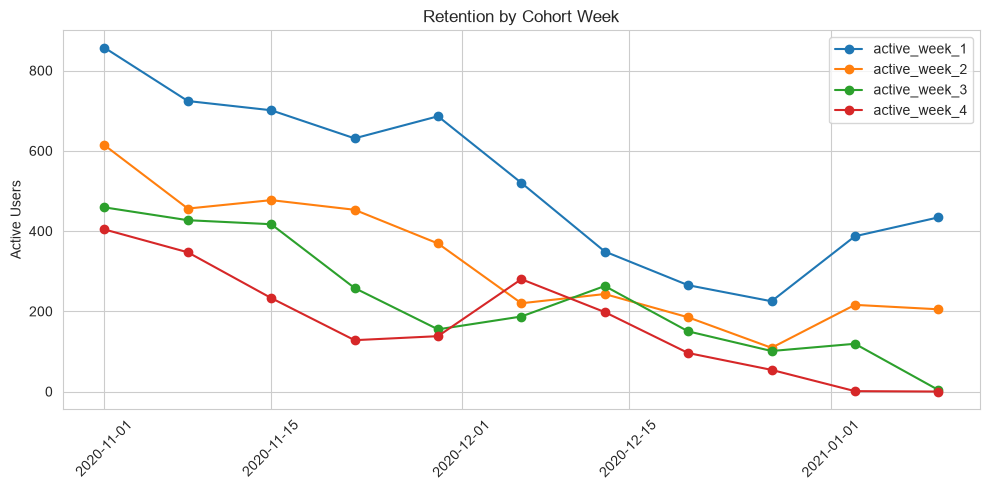

In [22]:
retention = dfs['retention'].set_index('cohort_week')[
    ['active_week_1', 'active_week_2', 'active_week_3', 'active_week_4']
]

# Note to self: rows near the end don't have enough runway for week_3/4 
# so drop them for a clean curve otherwise the lines drop weirdly
retention_clean = retention.iloc[:-3]

fig, ax = plt.subplots(figsize=(10, 5))

for col in retention_clean.columns:
    ax.plot(retention_clean.index, retention_clean[col], marker='o', label=col)

ax.set_ylabel('Active Users')
ax.set_title('Retention by Cohort Week')
ax.legend(loc='upper right') # added location just in case it covers lines
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/charts/retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Dec 6/13 cohorts look huge, probably holiday traffic. Need to check if they actually retain.


##### --- Chart 3: Funnel / Drop-off ---


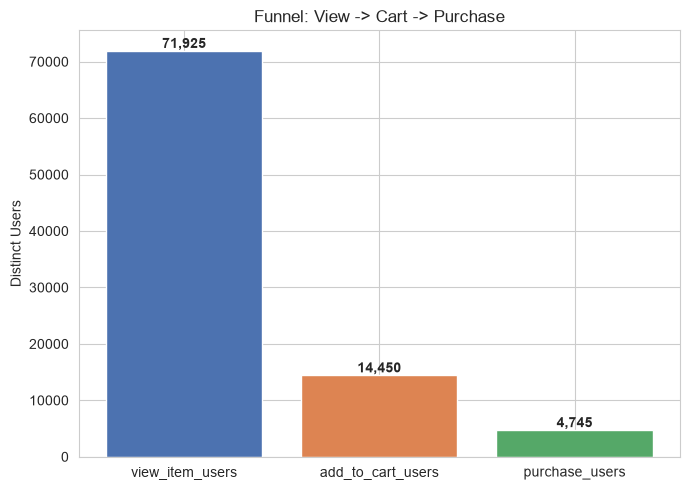

DEBUG -> view_item -> add_to_cart drop-off: 79.9%
DEBUG -> add_to_cart -> purchase drop-off: 67.2%


In [24]:

funnel_totals = dfs['funnel'][['view_item_users', 'add_to_cart_users', 'purchase_users']].sum()

fig, ax = plt.subplots(figsize=(7, 5))
# colors look okay, let's keep them distinct
funnel_colors = ['#4c72b0', '#dd8452', '#55a868']
ax.bar(funnel_totals.index, funnel_totals.values, color=funnel_colors)

for i, v in enumerate(funnel_totals.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

ax.set_title('Funnel: View -> Cart -> Purchase')
ax.set_ylabel('Distinct Users')
plt.tight_layout()
plt.savefig('../outputs/charts/funnel_dropoff.png', dpi=150, bbox_inches='tight')
plt.show()

# calculate dropoffs just to print out in logs
drop1 = (funnel_totals['view_item_users'] - funnel_totals['add_to_cart_users']) / funnel_totals['view_item_users']
drop2 = (funnel_totals['add_to_cart_users'] - funnel_totals['purchase_users']) / funnel_totals['add_to_cart_users']
print(f"DEBUG -> view_item -> add_to_cart drop-off: {drop1:.1%}")
print(f"DEBUG -> add_to_cart -> purchase drop-off: {drop2:.1%}")
# Biggest leak is definitely view -> cart. 

Note: 
summing across device/channel segments here is an approximation, not an exact match to the site wide funnel numbers from 01_exploration.sql (79.5%/64.8%), since a user could appear in more than one segment and get counted per segment rather than once overall. Close enough for this chart's purpose however it is not exact. 

##### --- Chart 4: Heatmap (Day of Week vs Country Revenue) ---


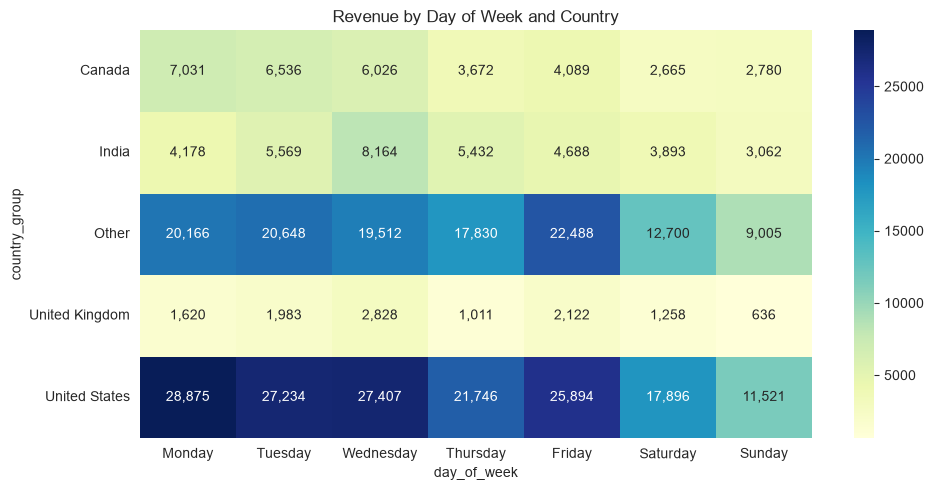

All charts generated successfully. Time to build the slides...


In [25]:


heatmap_data = dfs['geo'].pivot_table(
    index='country_group', 
    columns='day_of_week', 
    values='revenue', 
    aggfunc='sum'
)

# reorder days properly because alphabetical order is annoying
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data[day_order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt=',.0f', cmap='YlGnBu', ax=ax)

ax.set_title('Revenue by Day of Week and Country')
plt.tight_layout()
plt.savefig('../outputs/charts/daily_pattern_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("All charts generated successfully. Time to build the slides...")